In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Toyotacorolla - MLR.csv')
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [60]:
print(df.info())

# information about number od row/columns, datatypes & non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB
None


In [61]:
df.describe()

# Show's summary statistics for each numeric columns (count, mean, std, min, 25/50/75%, max).

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [62]:
df.median(numeric_only=True)

# Shows middle value of each numeric columns

Price         9900.0
Age_08_04       61.0
KM           63389.5
HP             110.0
Automatic        0.0
cc            1600.0
Doors            4.0
Cylinders        4.0
Gears            5.0
Weight        1070.0
dtype: float64

In [63]:
# Categorical summary
print(df['Fuel_Type'].value_counts())
print(df['Automatic'].value_counts())

# Frequency count for each categorical columns

Fuel_Type
Petrol    1264
Diesel     155
CNG         17
Name: count, dtype: int64
Automatic
0    1356
1      80
Name: count, dtype: int64


In [64]:
print(df.isnull().sum())

# Check for missing values per column -- dataset does not contain missing values

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64


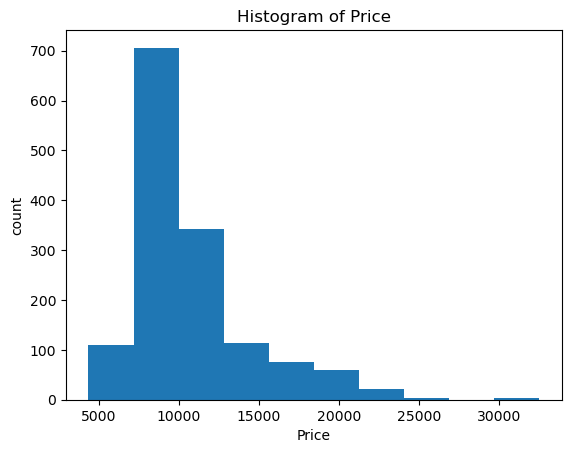

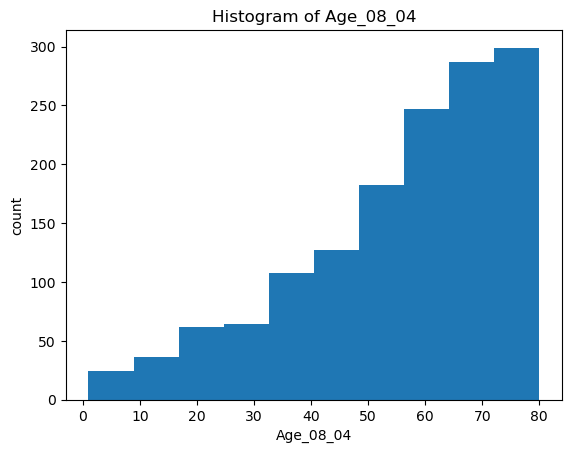

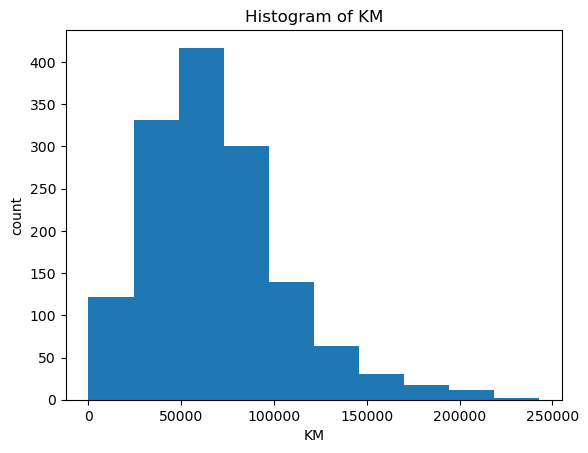

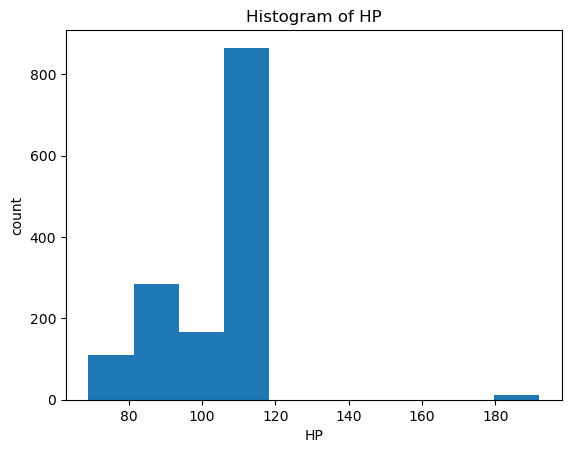

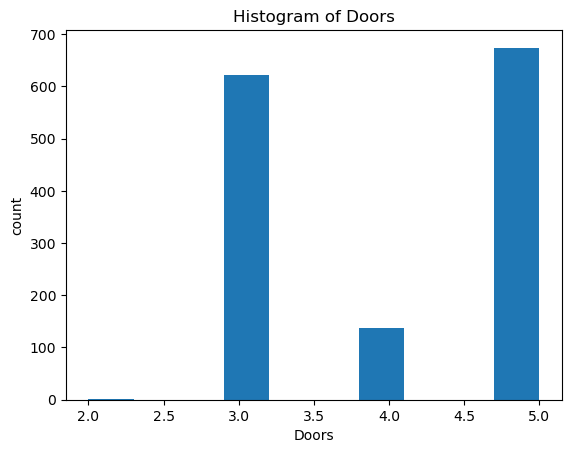

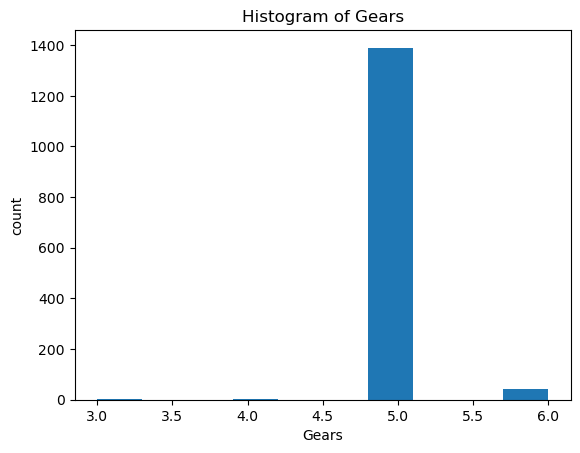

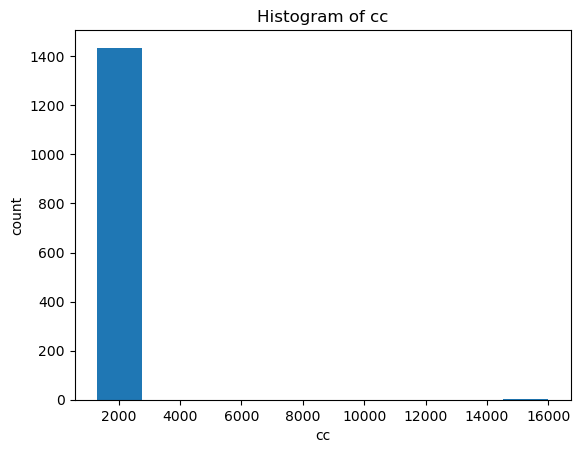

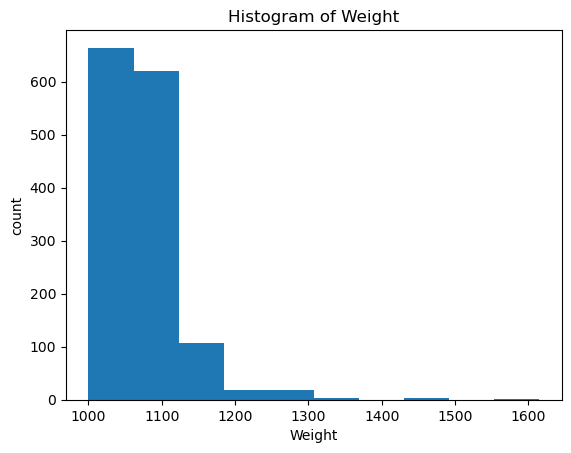

In [65]:
# Histograms for continuous variables

continuous_vars = ["Price", "Age_08_04", "KM", "HP", "Doors", "Gears", "cc", "Weight"]

for col in continuous_vars:
    plt.figure()
    plt.hist(df[col])
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()

# Histograms help us to detect outliers, skewness, and distribution shape.
# right-skewed variables are KM, Price, HP, cc, and Weight.
# left-skewed variables are Age_08_04.

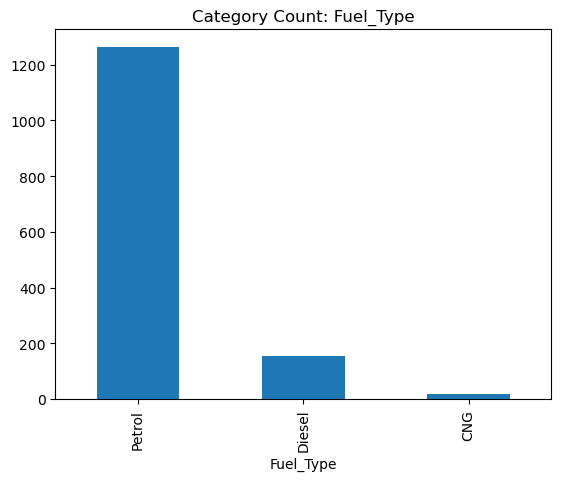

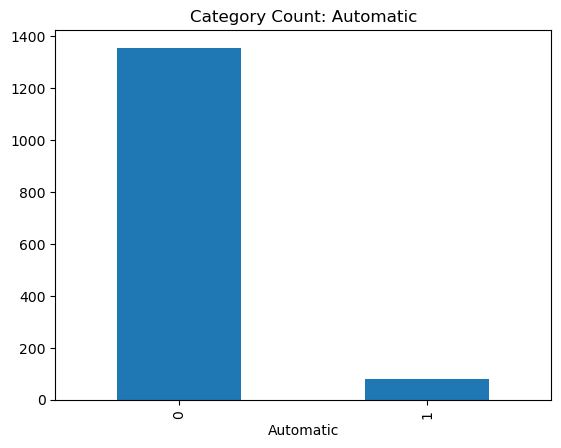

In [66]:
# Bar plots for categorical variables

categorical_vars = ["Fuel_Type", "Automatic"]

for col in categorical_vars:
    
    df[col].value_counts().plot(kind='bar')

    plt.title(f"Category Count: {col}")
    plt.show()


# Petrol is highest bar means most cars run on Petrol
# "0" is higher than "1" in Automatic means manual cars dominate the dataset

In [67]:
corr = df.corr(numeric_only=True)
corr

# correlations between numeric columns to see relationships with Price.

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
Price,1.000000,-0.876590,-0.569960,0.314990,0.033081,0.126389,0.185326,NaN,0.063104,0.581198
Age_08_04,-0.876590,1.000000,0.505672,-0.156622,0.031717,-0.098084,-0.148359,NaN,-0.005364,-0.470253
KM,-0.569960,0.505672,1.000000,-0.333538,-0.081854,0.102683,-0.036197,NaN,0.015023,-0.028598
HP,0.314990,-0.156622,-0.333538,1.000000,0.013144,0.035856,0.092424,NaN,0.209477,0.089614
Automatic,0.033081,0.031717,-0.081854,0.013144,1.000000,0.066740,-0.027654,NaN,-0.098555,0.057249
cc,0.126389,-0.098084,0.102683,0.035856,0.066740,1.000000,0.079903,NaN,0.014629,0.335637
Doors,0.185326,-0.148359,-0.036197,0.092424,-0.027654,0.079903,1.000000,NaN,-0.160141,0.302618
Cylinders,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gears,0.063104,-0.005364,0.015023,0.209477,-0.098555,0.014629,-0.160141,NaN,1.000000,0.020613
Weight,0.581198,-0.470253,-0.028598,0.089614,0.057249,0.335637,0.302618,NaN,0.020613,1.000000


In [68]:
# One-hot encoding for categorical variables

df_encoded = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)
df_encoded.head()

# Convert categorical variables into numeric form so regression algorithms can use them.

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,True,False
1,13750,23,72937,90,0,2000,3,4,5,1165,True,False
2,13950,24,41711,90,0,2000,3,4,5,1165,True,False
3,14950,26,48000,90,0,2000,3,4,5,1165,True,False
4,13750,30,38500,90,0,2000,3,4,5,1170,True,False


In [69]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Price', axis=1)  # features
y = df_encoded['Price']  # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# X: all features except target 'Price'
# y: the target variable
# 80% of the data for training, 20% of the data for testing.

In [70]:
# Model 1 — Linear Regression using all features
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model1 = LinearRegression()
model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

r2 = r2_score(y_test, y_pred1)
MSE = mean_squared_error(y_test, y_pred1)
print("Model 1 R²:", np.round(r2,2))
print("Model 1 MSE:", np.round(MSE,2))
VIF = 1/(1-r2)
print("VIF:",np.round(VIF,2))

# Coefficients interpretation
coeff_df1 = pd.DataFrame({
    "Feature": df_encoded.drop('Price', axis=1).columns,
    "Coefficient": model1.coef_
})
print(coeff_df1)

# Model explains 83% variation in Price.
# Positive coefficient increases the Price
# Negative coefficient decreases the Price

Model 1 R²: 0.83
Model 1 MSE: 2203043.82
VIF: 6.06
             Feature   Coefficient
0          Age_08_04 -1.208305e+02
1                 KM -1.623141e-02
2                 HP  1.403948e+01
3          Automatic  1.488309e+02
4                 cc -3.037219e-02
5              Doors -6.031097e+01
6          Cylinders  3.694822e-13
7              Gears  5.516007e+02
8             Weight  2.588496e+01
9   Fuel_Type_Diesel -6.854876e+01
10  Fuel_Type_Petrol  1.370809e+03


In [71]:
X2 = df_encoded[['Age_08_04', 'KM', 'HP', 'Weight']]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X2_train, y2_train)
y2_pred = model2.predict(X2_test)


r2 = r2_score(y2_test, y2_pred)
MSE = mean_squared_error(y2_test, y2_pred)
print("Model 2 R²:", np.round(r2,2))
print("Model 2 MSE:", np.round(MSE,2))
VIF = 1/(1-r2)
print("VIF:",np.round(VIF,2))

# Coefficients interpretation
coeff_df2 = pd.DataFrame({
    "Feature": X2_train.columns,
    "Coefficient": model2.coef_
})
print(coeff_df2)

# i took only few columns model performs better in R² and lower in MSE than Model 1
# R² = 0.85 means 85% of the changes in the target variable are explained by the model.
# model 2 is best model compared to other models but show some multicollinearity.

Model 2 R²: 0.85
Model 2 MSE: 1993321.01
VIF: 6.69
     Feature  Coefficient
0  Age_08_04  -120.025405
1         KM    -0.020233
2         HP    29.052170
3     Weight    19.769066


In [72]:
X3 = df_encoded[['Age_08_04','Doors','cc','Automatic','KM','Weight']]
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y, test_size=0.2, random_state=42)

model3 = LinearRegression()
model3.fit(X3_train, y3_train)
y3_pred = model3.predict(X3_test)


r2 = r2_score(y3_test, y3_pred)
MSE = mean_squared_error(y3_test, y3_pred)
print("Model 3 R²:", np.round(r2,2))
print("Model 3 MSE:", np.round(MSE,2))
VIF = 1/(1-r2)
print("VIF:",np.round(VIF,2))

# Coefficients interpretation
coeff_df3 = pd.DataFrame({
    "Feature": X3_train.columns,
    "Coefficient": model3.coef_ 
})
print(coeff_df3)

# Slight improvement over Model 2(VIF is decreased slightly compared to model 2)

Model 3 R²: 0.83
Model 3 MSE: 2233126.16
VIF: 5.97
     Feature  Coefficient
0  Age_08_04  -118.557578
1      Doors     3.667804
2         cc    -0.068047
3  Automatic   258.858480
4         KM    -0.024260
5     Weight    20.658729


In [73]:
from sklearn.linear_model import Lasso, Ridge

# Create Lasso model (alpha is regularization strength)
lasso = Lasso(alpha=0.1)  # you can tune alpha
lasso.fit(X_train, y_train)

# Predict
y_pred_lasso = lasso.predict(X_test)

# Evaluate
print("Lasso Regression Performance:")
print("R2 Score:", round(r2_score(y_test, y_pred_lasso), 2))
print("MSE:", round(mean_squared_error(y_test, y_pred_lasso), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_lasso)), 2))
VIF = 1/(1-r2_score(y_test, y_pred_lasso))
print("VIF:",np.round(VIF,2))

# Removes unimportant features by making coefficients zero
# Lasso gives good prediction performance(r2 = 0.83) and also performs feature selection by removing less important 
# coefficients, but the dataset still shows some multicollinearity.

Lasso Regression Performance:
R2 Score: 0.83
MSE: 2202270.26
RMSE: 1484.0
VIF: 6.06


In [74]:
# Create Ridge model
ridge = Ridge(alpha=1.0)  # alpha can be tuned
ridge.fit(X_train, y_train)

# Predict
y_pred_ridge = ridge.predict(X_test)

# Evaluate
print("Ridge Regression Performance:")
print("R2 Score:", round(r2_score(y_test, y_pred_ridge), 2))
print("MSE:", round(mean_squared_error(y_test, y_pred_ridge), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_ridge)), 2))
VIF = 1/(1-r2_score(y_test, y_pred_lasso))
print("VIF:",np.round(VIF,2))

# Reduces big coefficients but keeps all features
# Ridge performed slightly better(R2 = 0.84) than Lasso based on R2, MSE, and RMSE values.
# Both models achieved strong prediction performance, but some multicollinearity still exists (VIF = 6.06).

Ridge Regression Performance:
R2 Score: 0.84
MSE: 2199746.37
RMSE: 1483.15
VIF: 6.06


In [ ]:
# 1. What is Normalization & Standardization and how is it helpful?

# Normalization is a scaling technique that transforms data to a fixed range (typically 0–1) so that no feature dominates due to larger magnitude.
# Standardization converts data to zero mean and unit variance (µ = 0, σ = 1) so that features follow a standard normal distribution.
# Both techniques helps to improve model performance by removing scale differences, speeding up convergence, and preventing biased coefficient learning, 
# especially in algorithms like linear regression, KNN, SVM, neural networks, and clustering.

In [ ]:
# 2. What techniques can be used to address multicollinearity in multiple linear regression?

# To handle multicollinearity:

# Remove highly correlated variables (based on correlation matrix / VIF).
# Use Regularization techniques — Ridge (shrinks coefficients) and Lasso (eliminates irrelevant variables).
# Apply PCA to convert correlated variables into uncorrelated components.